# Residual variability quench vs LDA1

Test whether the **stimulus-onset quench** of neural variability tracks LDA1, and
whether that relationship is **behavioural (H1)** or **internal (H2)**.

Two variability measures, aligned to stimulus onset (PRE=(-0.2,0), POST=(0.1,0.3)):
- **rSC** — mean within-region across-trial noise correlation (coordinated variability)
- **FF**  — residual Fano factor `var(observed-predicted)/mean(observed)` (per-neuron), using the
  `ff_psth_ldabin.ipynb` var/mean definition applied to encoding residuals

Each computed at three **removal levels** using the encoding-model residuals:
- **raw** — nothing removed (total variability; no condition adjustment)
- **task** — task regressors removed (analogue of the condition-adjusted metric in the dedicated notebooks)
- **taskmotor** — task + motor(states) removed  ← the new test

`quench = pre - post` (>0 = variability drops at stimulus onset). If the quench↔LDA1
relationship dies once task+motor are removed → **H1 (behavioural)**; if it survives → **H2 (internal)**.

Functions live in `variability_functions.py`; this notebook is the analysis driver.

In [1]:
import os, glob, pickle, importlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from iblatlas.atlas import BrainRegions
import encoding_functions as ef
import variability_functions as vf
importlib.reload(ef); importlib.reload(vf)

prefix = '/home/ines/repositories/'
neur = prefix + 'representation_learning_variability/paper-individuality/neural/'
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
neuron_dir = prefix + 'representation_learning_variability/paper-individuality/data/neuron_files/'

lda = pd.read_pickle(data_path + 'mouse_LDA_5_bins_cut06-07-2026').rename(columns={0: 'lda_1'})

# fine acronym -> Beryl region (collapse cortical layers etc.)
_br = BrainRegions(); _cache = {}
def beryl(a):
    if a in _cache: return _cache[a]
    try: v = _br.id2acronym(_br.remap(_br.acronym2id(a), source_map='Allen', target_map='Beryl'))[0]
    except Exception: v = None
    _cache[a] = v; return v

## Sweep: residual variability quench per session × region (cached, resumable)

In [2]:
results_dir = 'residual_quench'
os.makedirs(results_dir, exist_ok=True)
pids = [os.path.basename(f).replace('states_neurons_file_', '')
        for f in glob.glob(neuron_dir + 'states_neurons_file_*')]
N_PROBES = len(pids)                 # all available probes (cache is resumable)

for i, pid in enumerate(pids[:N_PROBES]):
    cache = os.path.join(results_dir, pid + '.parquet')
    if os.path.exists(cache):
        continue
    try:
        with open(neuron_dir + 'states_neurons_file_' + pid, 'rb') as f:
            df = pickle.load(f)
        tbl, alpha = vf.residual_quench(df, region_of=beryl, min_neurons=8)
        if len(tbl) == 0:
            continue
        tbl['pid'] = pid; tbl['session'] = df['session'].iloc[0]; tbl['mouse_name'] = df['mouse_name'].iloc[0]
        tbl.to_parquet(cache)
        print(f'[{i+1}/{N_PROBES}] {pid[:8]}: {len(tbl)} regions', flush=True)
    except Exception as e:
        print(f'[{i+1}/{N_PROBES}] {pid[:8]} FAIL {type(e).__name__}: {e}', flush=True)
print('cached probes:', len(glob.glob(results_dir + '/*.parquet')))

/home/ines/repositories/representation_learning_variability/paper-individuality/neural/encoding/variability_functions.py:45: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(Rfull[a:b, :], axis=0)


[346/380] 7b05cccc: 6 regions


/home/ines/repositories/representation_learning_variability/paper-individuality/neural/encoding/variability_functions.py:45: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(Rfull[a:b, :], axis=0)


[347/380] 7441d0df: 2 regions


[348/380] eb7e9f3f: 3 regions


...

[378/380] 55423355: 4 regions


/home/ines/repositories/representation_learning_variability/paper-individuality/neural/encoding/variability_functions.py:45: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(Rfull[a:b, :], axis=0)


[379/380] 4d2e7e49: 1 regions


[380/380] b976e816: 5 regions


cached probes: 375


## Aggregate + quench magnitudes

In [3]:
tbl = pd.concat([pd.read_parquet(f) for f in glob.glob(results_dir + '/*.parquet')], ignore_index=True)
tbl = tbl.rename(columns={'region': 'area'})
tbl = tbl[tbl['area'].notna() & (tbl['area'] != 'root')].copy()
LEVELS = ['raw', 'task', 'taskmotor']
for lvl in LEVELS:
    tbl[f'rSC_quench_{lvl}'] = tbl[f'rSC_pre_{lvl}'] - tbl[f'rSC_post_{lvl}']
    tbl[f'ff_quench_{lvl}']  = tbl[f'ff_pre_{lvl}']  - tbl[f'ff_post_{lvl}']
print(f'{len(tbl)} session x region rows | {tbl["pid"].nunique()} probes | '
      f'{tbl["session"].nunique()} sessions | {tbl["mouse_name"].nunique()} mice\n')
sess = tbl.groupby('session')[[f'{m}_quench_{l}' for m in ['rSC','ff'] for l in LEVELS]].mean()
print('mean quench per level (session-level; >0 = quenched at stim onset):')
print(sess.mean().round(4).to_string())

1119 session x region rows | 364 probes | 238 sessions | 56 mice

mean quench per level (session-level; >0 = quenched at stim onset):
rSC_quench_raw          0.0022
rSC_quench_task         0.0040
rSC_quench_taskmotor    0.0041
ff_quench_raw          -0.0316
ff_quench_task          0.1179
ff_quench_taskmotor     0.1265


## Does the quench track LDA1?  (H1 behavioural vs H2 internal)

Session-stratified permutation + partial-correlation JZS Bayes factor (region + n_neurons
controlled), BH-FDR across the family. Compare the slope across removal levels:
raw → task → task+motor. Attenuation to null after removing task+motor ⇒ H1; survival ⇒ H2.

In [4]:
targets = [f'{m}_quench_{l}' for m in ['rSC', 'ff'] for l in LEVELS]
rows = []
for t in targets:
    r = ef.lda1_perm_bf(tbl, lda, target=t, region_col='area', extra_covars=('n_neurons',),
                        perm_group='session', min_area_n=0, n_perm=2000)
    if r: rows.append(r)
res = pd.DataFrame(rows)
res['measure'] = res['target'].str.split('_quench_').str[0]
res['level']   = res['target'].str.split('_quench_').str[1]
res['q_perm_BH'] = multipletests(res['p_perm'], method='fdr_bh')[1].round(3)
res[['measure', 'level', 'n', 'n_groups', 'r_partial', 'bf10', 'p_perm', 'q_perm_BH']].round(4)

[rSC_quench_raw] slope=+0.0003005  r_partial=+0.043  BF10=0.097 (strong H0)  p_perm=0.2350  | 1119 neurons, 238 sessions


[rSC_quench_task] slope=+0.0002193  r_partial=+0.035  BF10=0.0727 (strong H0)  p_perm=0.3230  | 1119 neurons, 238 sessions


[rSC_quench_taskmotor] slope=+1.015e-05  r_partial=+0.002  BF10=0.0415 (strong H0)  p_perm=0.9610  | 1119 neurons, 238 sessions


[ff_quench_raw ] slope=+0.005703  r_partial=+0.029  BF10=0.0615 (strong H0)  p_perm=0.4315  | 1118 neurons, 238 sessions


[ff_quench_task] slope=+0.003463  r_partial=+0.018  BF10=0.0482 (strong H0)  p_perm=0.6115  | 1118 neurons, 238 sessions


[ff_quench_taskmotor] slope=-0.00196  r_partial=-0.011  BF10=0.0437 (strong H0)  p_perm=0.7590  | 1118 neurons, 238 sessions


,measure,level,n,n_groups,r_partial,bf10,p_perm,q_perm_BH
0,rSC,raw,1119,238,0.0432,0.0970,0.2350,0.863
1,rSC,task,1119,238,0.0351,0.0727,0.3230,0.863
2,rSC,taskmotor,1119,238,0.0019,0.0415,0.9610,0.961
3,ff,raw,1118,238,0.0294,0.0615,0.4315,0.863
4,ff,task,1118,238,0.0182,0.0482,0.6115,0.911
5,ff,taskmotor,1118,238,-0.0108,0.0437,0.7590,0.911


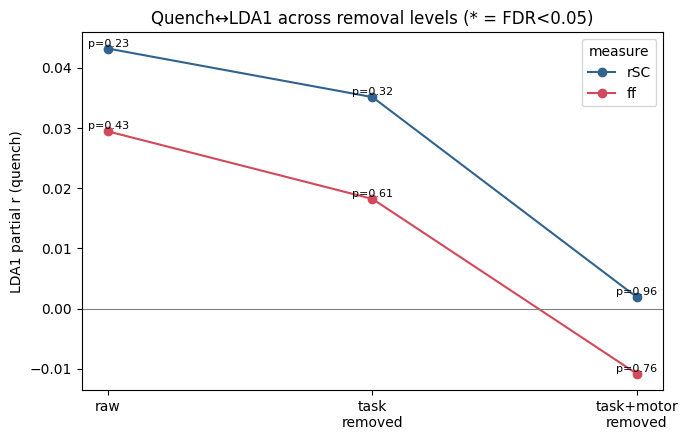

In [5]:
# LDA1 effect (partial r) across removal levels: does it attenuate when task/motor removed?
fig, ax = plt.subplots(figsize=(7, 4.5))
order = {'raw': 0, 'task': 1, 'taskmotor': 2}
for m, col in [('rSC', '#30638e'), ('ff', '#d1495b')]:
    d = res[res['measure'] == m].copy()
    d['x'] = d['level'].map(order)
    d = d.sort_values('x')
    ax.plot(d['x'], d['r_partial'], '-o', color=col, label=m)
    for _, rr in d.iterrows():
        mark = '*' if rr['q_perm_BH'] < 0.05 else ''
        ax.annotate(f"p={rr['p_perm']:.2f}{mark}", (rr['x'], rr['r_partial']),
                    fontsize=8, ha='center', va='bottom')
ax.axhline(0, color='grey', lw=.8)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['raw', 'task\nremoved', 'task+motor\nremoved'])
ax.set(ylabel='LDA1 partial r (quench)', title='Quench↔LDA1 across removal levels (* = FDR<0.05)')
ax.legend(title='measure')
plt.tight_layout(); plt.show()